In [5]:
import numpy as np
import random
import matplotlib.pyplot as plt
%matplotlib inline

Building the dataset with a sherlock holmes book as the source.

In [6]:
# downloading text
import urllib.request
import re

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
urllib.request.urlretrieve(url, "shakespeare.txt")

text = open("shakespeare.txt").read().lower()

# clean up extra blank lines
text = re.sub(r'\n\s*\n', '\n', text)

# split by newlines (shakespeare has one line per speaker)
lines = text.split('\n')
lines = [line.strip() for line in lines if line.strip()]

# join back and split on punctuation
text = ' '.join(lines)
sentences = re.split(r'[.!?]+', text)
sentences = [s.strip().split() for s in sentences if len(s.strip().split()) > 3]

# building word to int mapping
vocab = sorted(list(set(word for sentence in sentences for word in sentence)))
wtoi = {w:i+1 for i,w in enumerate(vocab)}
wtoi['<S>'] = 0
itow = {i:w for w,i in wtoi.items()}
vocab_size = len(itow)
print(vocab_size)

# building the actual dataset
context_size = 4
def build_dataset(sentences):
    X, Y = [], []

    for sentence in sentences:
        context = [0] * context_size
        for word in sentence:
            ix = wtoi[word]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
        
        # ADDING THIS AFTER LOTS OF DEBUGGING and realizing i forgot to add the stop token
        X.append(context)
        Y.append(0)

    return np.array(X), np.array(Y)

random.shuffle(sentences)
n1 = int(0.8*len(sentences))
n2 = int(0.9*len(sentences))
Xtr, Ytr = build_dataset(sentences[:n1])
Xdev, Ydev = build_dataset(sentences[n1:n2])
Xte, Yte = build_dataset(sentences[n2:])

19598


In [7]:
Xtr.shape, Ytr.shape

((168580, 4), (168580,))

now that i have the datasets in X and Y, i'll start building the model!
* my goal is to be able to customize the number of dimensions/layers/neurons in the model, so i'll build a class for the model

In [8]:
class MLP:
    def __init__(self, Xtr, Ytr, batch_size, dims, vocab_size):
        self.Xtr = Xtr
        self.Ytr = Ytr
        self.batch_size = batch_size
        self.dims = dims
        self.vocab_size = vocab_size

        self.layers = []
        self.lossi = []
        self.lr = 0
        self.Yb = []
        self.training = False
    
    def matmul(self, h, W, b = None):
        # c = np.zeros((h.shape[0], W.shape[1]))
        # for i in range(h.shape[0]):
        #     for k in range(W.shape[1]):
        #         for j in range(h.shape[1]):
        #             c[i,k] += h[i,j] * W[j,k]

        # testing with np.dot so training doesnt take super long
        c = np.dot(h, W)

        if b is not None:
            c += b
        return c
    
    class InputLayer:
        def __init__(self, parent):
            self.C = np.random.randn(parent.vocab_size, parent.dims) * 0.1

            # appending to model
            parent.layers.append(self)      
        
        def forward(self, parent, input):
            if parent.training:
                # print("input layer forward")
                # samples from training set to get the batch
                if parent.batch_size == Xtr.shape[0]:
                    self.Xb, parent.Yb = Xtr, Ytr
                else:
                    ix = np.random.randint(0, parent.Xtr.shape[0], (parent.batch_size,))
                    self.Xb, parent.Yb = Xtr[ix], Ytr[ix]

                # get batch embeddings by indexing into C
                emb = self.C[self.Xb]

                # reshape from 2d into 1d array
                emb = emb.reshape(emb.shape[0], -1)
                
                return emb
            else:
                emb = self.C[np.array([input])]
                emb = emb.reshape(1, -1)
                return emb
        
        def backward(self, parent, dout):
            # print("input layer back")
            demb = dout.reshape(parent.batch_size, -1, parent.dims)
            dC = np.zeros((parent.vocab_size, parent.dims))
            for i in range (self.Xb.shape[0]):
                for j in range(self.Xb.shape[1]):
                    dC[self.Xb[i,j]] += demb[i,j]
            
            # updating C
            self.C += -parent.lr * dC
            
            return dC # returning for consistency
    
    class LinearLayer:
        def __init__(self, parent, nin, nout):
            # defining weights & biases
            if nout == parent.vocab_size:  # output projection layer
                w_scale = 0.01
            else:
                w_scale = (np.sqrt(2)) / (nin**0.5)
            self.W = np.random.randn(nin, nout) * w_scale # kaiming every layer to address pre-activation range issues (except the one before softmax)
            self.b = np.zeros(nout) # np.random.randn(nout) * 0.1

            # appending to model
            parent.layers.append(self)
        
        def forward(self, parent, input):
            # print("linear layer forward")
            self.input = input

            # exectues input @ W + b
            return parent.matmul(input, self.W, self.b)
        
        def backward(self, parent, dout):
            # print("linear layer back")
            dinput = parent.matmul(dout, self.W.T)
            dW = parent.matmul(self.input.T, dout)
            db = np.sum(dout, axis=0)

            # updating W * b
            self.W += -parent.lr * dW
            self.b += -parent.lr * db
            return dinput
    
    class BatchNorm:
        def __init__(self, parent, nin):
            self.bngain = np.random.randn(1, nin) * 0.01 + 1.0
            self.bnbias = np.zeros((1, nin)) # changing from rand dist to zeros in efforts to reduce tanh

            self.running_mean = np.zeros((1, nin))
            # self.running_mean = np.ones((1, nin)) * 0.1
            self.running_var = np.ones((1, nin))
            self.mean = np.zeros((1, nin))
            self.var = np.ones((1, nin))


            parent.layers.append(self)
        
        def forward(self, parent, input):
            # print("batch norm forward")
            self.input = input
            if parent.training:
                # handles the case where there is only 1 value in the "batch"
                if(input.shape[0]==1):
                    out = self.bngain * input + self.bnbias
                    return out
                
                # else, goes through regular batch norm
                bnmean = np.mean(input, axis=0, keepdims=True)
                self.bnvar = np.var(input, axis=0, keepdims=True, ddof=0) # ddof=1 makes the denominator N-1 for bessel's correction

                self.running_mean = 0.9 * self.running_mean + 0.1 * bnmean
                self.running_var = 0.9 * self.running_var + 0.1 * self.bnvar

                if parent.batch_size == Xtr.shape[0]:
                    self.mean = bnmean
                    self.var = self.bnvar

                # print("batch mean range:", bnmean.min(), bnmean.max())
                # print("running_mean range:", self.running_mean.min(), self.running_mean.max())
                # print("batch mean std:", bnmean.std())
                
                self.normedbatch = (input-bnmean)/((self.bnvar + 1e-5) ** 0.5) # z-scores batch with epsilon to prevent 0 division
            
            else:
                self.normedbatch = (input-self.running_mean)/((self.running_var + 1e-5) ** 0.5)
            
            return self.bngain * self.normedbatch + self.bnbias
        
        def backward(self, parent, dout):
            # print("batch norm back")
            dbngain = np.sum(self.normedbatch * dout, axis=0, keepdims=True)
            dbnbias = np.sum(dout, axis=0, keepdims=True)

            # using a condensed formuala derived arithmetically on paper
            N = parent.batch_size
            dinput = (self.bngain/((self.bnvar + 1e-5)**0.5))/N * (N * dout - dbnbias - self.normedbatch * dbngain) # removing bessel's correction

            # updating gain and bias
            # # adding a weight decay on bngain to prevent it from growing too much
            # self.bngain *= (1 - parent.lr * dbngain) # shrinks bngain a bit every time
            self.bngain += -parent.lr * dbngain
            self.bnbias += -parent.lr * dbnbias

            return dinput
        
        def show_distributions(self):
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
            ax1.hist(self.input.reshape(-1), 50)
            ax1.set_title("pre-bn distribution")
            
            ax2.hist(self.normedbatch.reshape(-1), 50)
            ax2.set_title("bn output distribution")
            
            plt.tight_layout()
        
        def get_running(self):
            # print(self.running_mean, self.running_var)
            print("running_mean range:", self.running_mean.min(), self.running_mean.max())
            print("running_var range:", self.running_var.min(), self.running_var.max())
    

    class Tanh:
        def __init__(self, parent):
            parent.layers.append(self)
        
        def forward(self, parent, input):
            # print("tanh forward")
            self.input = input
            self.tanhvals = np.tanh(input)
            return self.tanhvals
        
        def backward(self, parent, dout):
            # print("tanh back")
            return (1-(self.tanhvals)**2) * dout
        
        def show_distributions(self):
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
            ax1.hist(self.input.reshape(-1), 50)
            ax1.set_title("pre-tanh distribution")
            
            ax2.hist(self.tanhvals.reshape(-1), 50)
            ax2.set_title("tanh output distribution")
            
            plt.tight_layout()
    
    class ReLU:
        def __init__(self, parent):
            parent.layers.append(self)
        def forward(self, parent, input):
            self.input = input
            self.reluvals = np.maximum(0, input)
            return self.reluvals
        def backward(self, parent, dout):
            dinput = dout.copy()
            dinput[self.input <= 0] = 0
            return dinput
        def show_distributions(self):
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
            ax1.hist(self.input.reshape(-1), 50)
            ax1.set_title("pre-relu distribution")
            
            ax2.hist(self.reluvals.reshape(-1), 50)
            ax2.set_title("relu output distribution")
            
            plt.tight_layout()


    
    class SoftMax:
        def __init__(self, parent):
            parent.layers.append(self)

        def forward(self, parent, input):
            # print("softmax forward")
            if parent.batch_size == Xtr.shape[0]:
                return []
            
            self.logits = input

            # normalizing logits
            logit_maxes = np.max(self.logits, axis=1, keepdims=True)
            norm_logits = self.logits - logit_maxes

            # creating probabilities for each output possibility
            counts = np.exp(norm_logits)
            counts_sum = np.sum(counts, axis=1, keepdims=True)
            self.probs = counts/counts_sum

            return self.probs
        
        def loss(self, parent):
            logprobs = np.log(self.probs)
            loss = -np.mean(logprobs[range(parent.batch_size), parent.Yb])
            return loss
        
        def backward(self, parent, dout):
            # print("softmax back")
            dlogits = self.probs.copy()
            dlogits[range(parent.batch_size), parent.Yb] -= 1
            dlogits /= parent.batch_size
            return dlogits
        
        def get_probs(self):
            return self.probs
    
    def forward(self):
        output = []
        for layer in self.layers:
            output = layer.forward(self, output)

        if self.training:
            loss = self.layers[-1].loss(self)
            return loss
        else:
            return output
    
    def backward(self):
        dout = []
        for layer in reversed(self.layers):
            dout = layer.backward(self, dout)
    
    def calc_mean_var(self):
        self.training = True
        temp = self.batch_size
        self.batch_size = Xtr.shape[0]
         
        # forward pass through model and update mean/var at every batchnorm layer
        self.forward()
        self.batch_size = temp
        self.training = False
    
    def get_running_vars(self):
        for index, layer in enumerate(self.layers):
            # print(index, layer)
            if isinstance(layer, self.BatchNorm):
                layer.get_running()

    def train(self, steps, lr1, lr2):
        self.training = True
        self.lr = lr1
        for i in range(steps):
            if i > steps//2:
                self.lr = lr2
            
            # forwards and backwards pass
            loss = self.forward()
            self.lossi.append(loss)
            self.backward()
            
            # printing loss periodically
            if i % (steps//20) == 0:
                print(f"{i}/{steps}: loss={loss:.4f}")
                # for index, layer in enumerate(self.layers):
                #     # print(index, layer)
                #     if isinstance(layer, (self.Tanh, self.ReLU, self.BatchNorm)):
                #         layer.show_distributions()
                #         plt.show()
                    # if isinstance(layer, (self.BatchNorm)):
                    #     layer.get_running()
        
        # show distribution before tanh to check if scaling is needed
        # for index, layer in enumerate(self.layers):
        #     # print(index, layer)
        #     if isinstance(layer, (self.Tanh, self.BatchNorm)):
        #         layer.show_distributions()
        #         plt.show()
        
        self.training = False
        print(f"{steps}/{steps}: loss={loss:.4f}") 
    
    def plotloss(self):
        plt.plot(self.lossi)
    
    def get_prob(self):
        return self.layers[-1].get_probs()

    def sample(self, num_samples, context_size = context_size):
        self.training = False

        for _ in range(num_samples):
            out = []
            context = [0] * context_size

            while True:
                # call forward() on all layers normally
                x = context # gives context as input to inputlayer
                for layer in self.layers:
                    x = layer.forward(self, x)
                x = x[0] # reshaping into 1d array

                ix = np.random.choice(len(x), p=x)
                context = context[1:] + [ix]
                # print(itow[ix])

                if ix == 0:
                    break
                
                out.append(ix)

            print((' '.join(itow[i] for i in out)) + '.')
    
    def evaluate_loss(self, X, Y):
        self.training = False
        total_loss = 0
        batch_count = 0
        for i in range(0, X.shape[0], self.batch_size):
            j = min(i + self.batch_size, X.shape[0])
            Xb, self.Yb = X[i:j], Y[i:j]

            x = self.layers[0].C[Xb].reshape(j - i, -1)
            for layer in self.layers[1:]:
                x = layer.forward(self, x)
            
            logprobs = np.log(x + 1e-8)
            loss = -np.mean(logprobs[range(j - i), self.Yb])
            total_loss += loss
            batch_count += 1
        
        return total_loss/batch_count # avg loss over all the batches
            
                

my first round of training:

In [26]:
# initialize model
dims = 32
model = MLP(Xtr, Ytr, batch_size = 64, dims = dims, vocab_size = vocab_size)

# add layers
model.InputLayer(model)
model.LinearLayer(model, context_size*dims, 256)
model.BatchNorm(model, 256)
model.Tanh(model)
model.LinearLayer(model, 256, vocab_size)
model.SoftMax(model)

In [27]:
# train model
model.train(10000,0.2,0.01) # this is a retrain w my finalized model

0/10000: loss=9.8982
500/10000: loss=7.6224
1000/10000: loss=6.9570
1500/10000: loss=6.5670
2000/10000: loss=6.9132
2500/10000: loss=6.4277
3000/10000: loss=6.7281
3500/10000: loss=6.0112
4000/10000: loss=6.2422
4500/10000: loss=6.4543
5000/10000: loss=5.6370
5500/10000: loss=5.5397
6000/10000: loss=6.0858
6500/10000: loss=5.9815
7000/10000: loss=6.2789
7500/10000: loss=6.1453
8000/10000: loss=5.7947
8500/10000: loss=5.9037
9000/10000: loss=6.7438
9500/10000: loss=6.2369
10000/10000: loss=5.8073


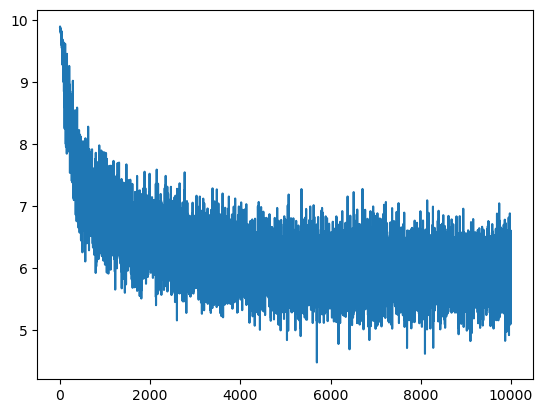

In [161]:
model.plotloss()

## concerns about tanh saturation

after my first (successful) round of training at 10,000 iterations with 0.2 lr and 0.1 lr for the first and second half , 32 batch size, 32 dimensions, and one linear layer with 256 neurons, this is the distribution of values being inputted into the tanh layer:

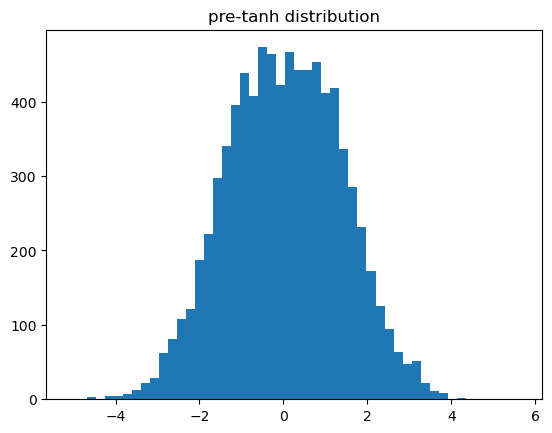

i'm concerned that many values are being squashed to -1 and 1. i'm going to intialize biases to 0 and scale down the W before softmax by 0.01 instead of 0.1. this is the distribution of values being inputted into the tanh layer now:

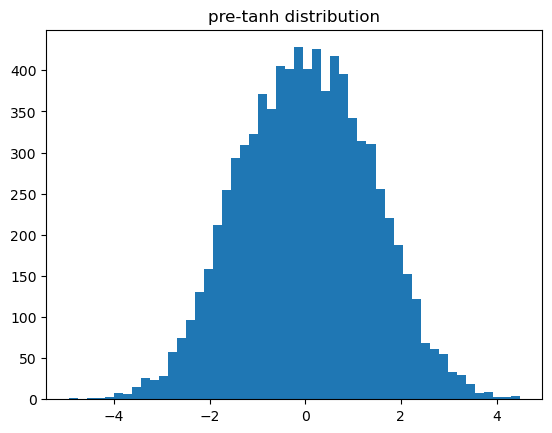

not much has changed. i'm also noticing that loss is bouncing around too much. here is how it looks:<br>
0/10000: loss=9.9123 <br>
500/10000: loss=8.0236<br>
1000/10000: loss=7.0152<br>
1500/10000: loss=6.7371<br>
2000/10000: loss=6.7829<br>
2500/10000: loss=7.1125<br>
3000/10000: loss=6.8404<br>
3500/10000: loss=6.2051<br>
4000/10000: loss=6.3526<br>
4500/10000: loss=7.1172<br>
5000/10000: loss=6.6011<br>
5500/10000: loss=5.4897<br>
6000/10000: loss=6.2460<br>
6500/10000: loss=6.7360<br>
6500/10000: loss=6.7360<br>
7000/10000: loss=6.2458<br>
7500/10000: loss=7.0233<br>
8000/10000: loss=6.0930<br>
8500/10000: loss=5.9284<br>
9000/10000: loss=6.2687<br>
9500/10000: loss=6.0733<br>
i'm decreasing learning rate to 0.1 for the first half and 0.01 for the second half and increasing the batch size to 64. i'm also going to plot tanh output to see if the range issue is actually a real issue.

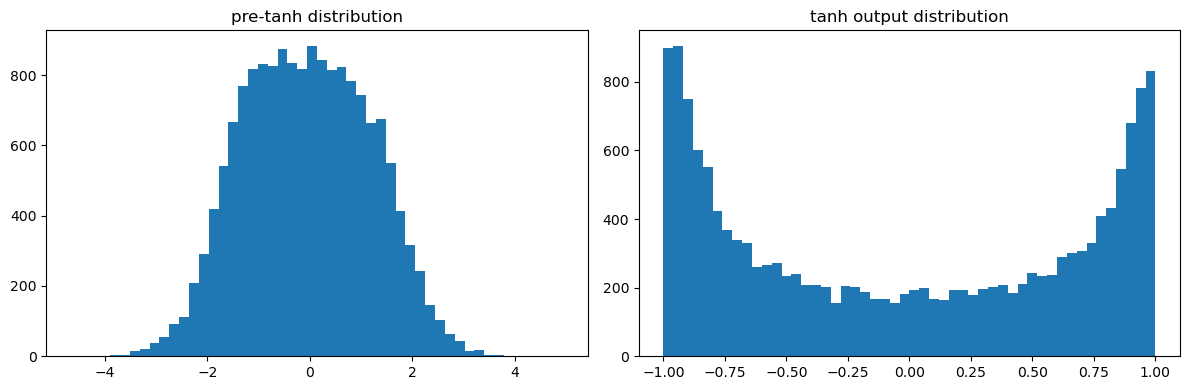

the tanh saturation definitely is a real issue. also lr is still bouncing a bit.

i'm going to dig deep into this tanh problem. this is the first iteration pre and post tanh and bn distribution :

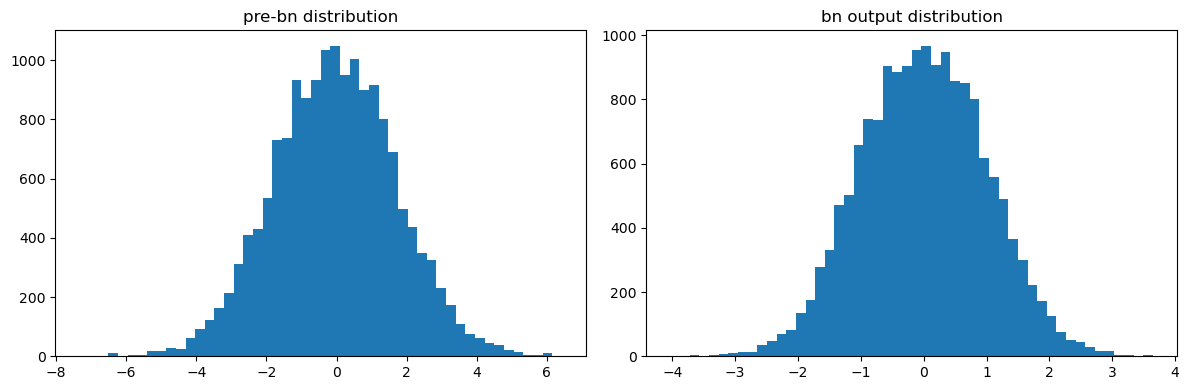

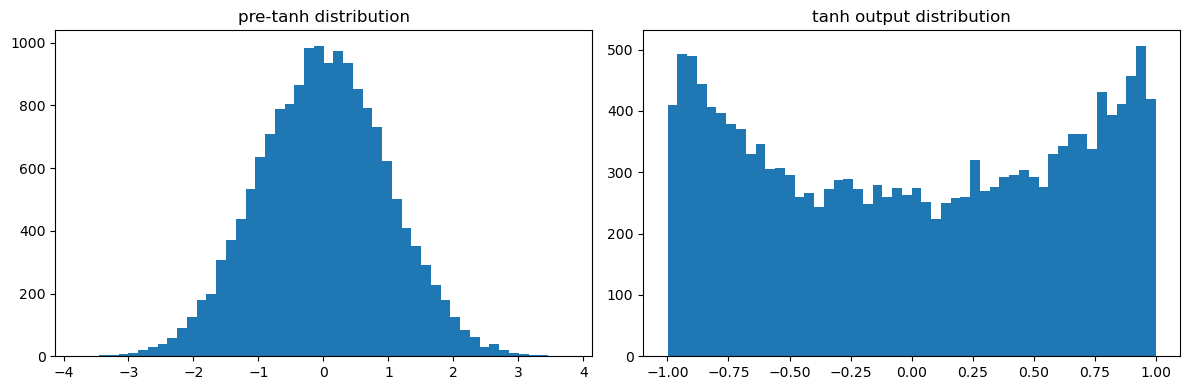

at this point, i'm thinking we just need to make the nueral network a little bigger. i added another set of linear, bn, and tanh so that it can renormalize after the previous one. it seems to be producing better results, though there is still some saturation. solving the same problem on a bigger scale doesn't feel like the right idea. so, i'm going back to the simple layer now and will try to scale down C values by 0.1 since i wasn't scaling earlier.

good news! scaling C brought down my loss to around 5.9 which is the lowest i've gotten so far. there's still tanh saturation as you can see:

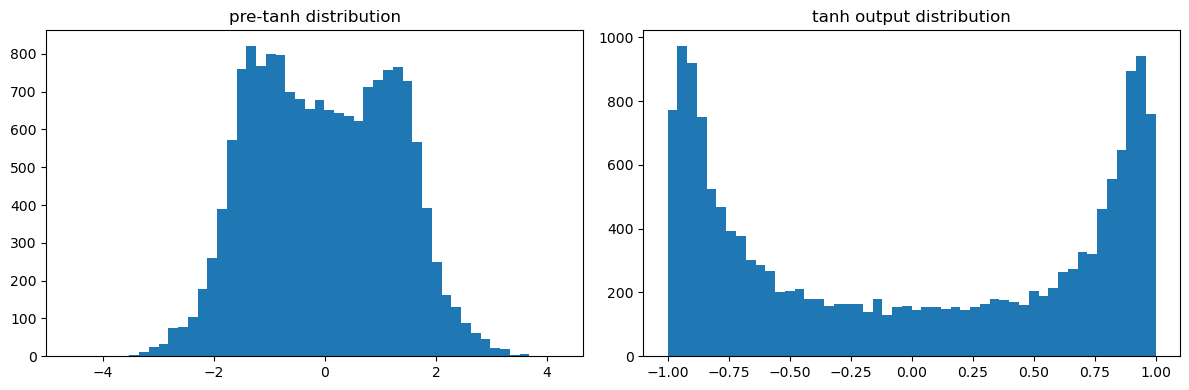

i'm going to try using relu with a lower lr.

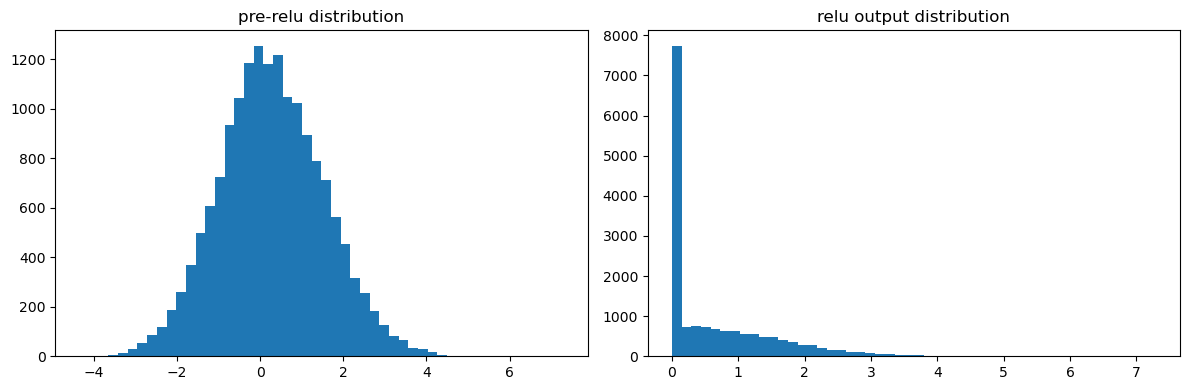

relu doesn't seem to be the solution. there were about 8500 0 values in the relu output on iteration 1 and its around 7500 on iteration 10000, so clearly the neurons are dying and EARLY. next, i'm going back to tanh but removing bessel's correction for var calculation in bn.

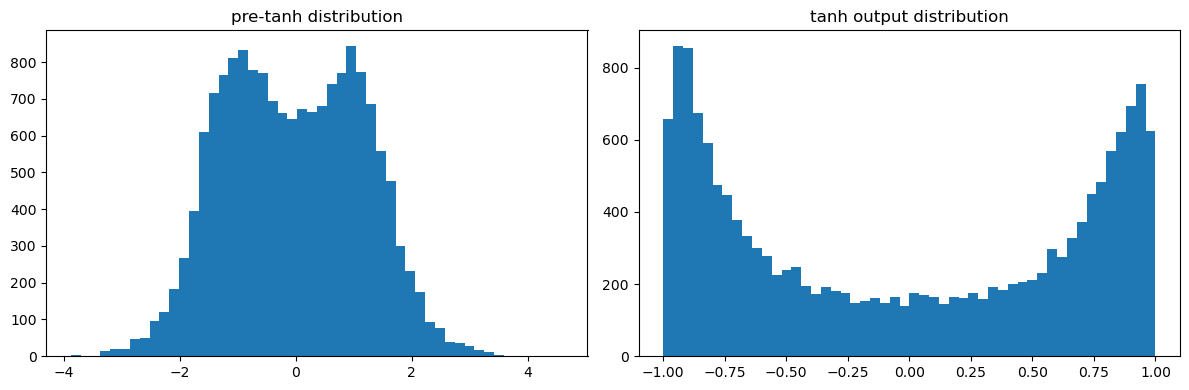

but here's the graph at the 1000/10000 iteration mark:

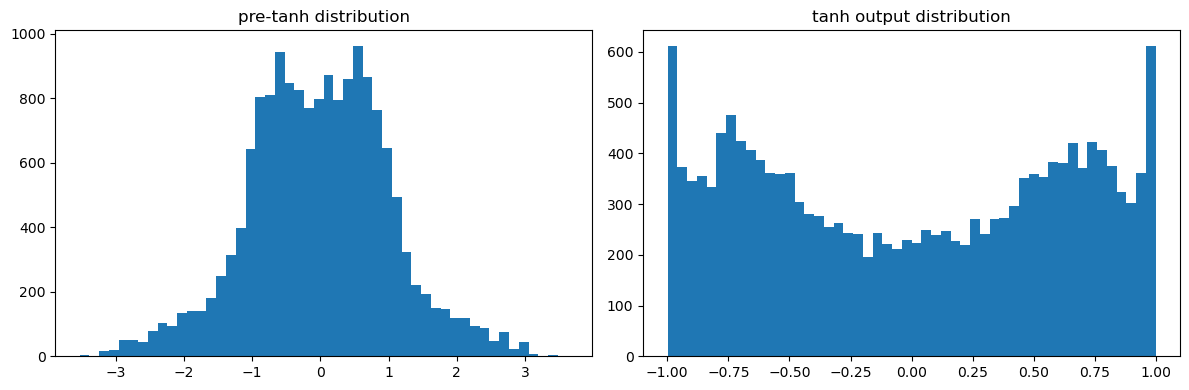

so maybe they are no longer be killed off by accident and actually just migrating to -1/1 based on the training loop. i think i'm okay to proceed now considering the saturation at -1/1 is happening over time. i'm guessing this is actually the neurons training to represent the least likely values in the dataset.

## fixing the sampling output

now it's time to tackle the second issue. when sampling from the model, i get obscenely long sentences that never end. 

first, i'm thinking my running mean and var might be inaccurate so i'm switching to calculating it manually. i defined a function called calc_mean_var() in the MLP class that i'll call before sampling. this will give us the true Xtr mean/var for the scenario with one batchnorm layer.

In [46]:
# # model.calc_mean_var()
# # calc_mean_var took too long to run but it was able to print these values:
true_mean = np.array([[
     0.05505510, -0.02441399,  0.01680632,  0.01342653, -0.03301763, -0.03257108,
    -0.01391370,  0.05603302,  0.05020995,  0.00628049,  0.03459979,  0.03184342,
     0.01818097, -0.01161411, -0.01589182,  0.03335142, -0.04542839, -0.04275170,
    -0.00864267, -0.03298012, -0.04050593, -0.02112501, -0.00079126,  0.00103371,
     0.05311937,  0.01606713,  0.00493106,  0.01027342, -0.00493288, -0.01404335,
    -0.01271702,  0.01973719, -0.01175247, -0.02156882, -0.00403991, -0.05016794,
     0.02152932, -0.04426600, -0.03485420, -0.01951461, -0.02285113,  0.00736646,
    -0.01106215, -0.03286913,  0.04899088,  0.02068901,  0.02057042,  0.05136832,
     0.02955422, -0.03169590, -0.02554140,  0.02774703,  0.05831096,  0.04236679,
    -0.01727133, -0.00254619, -0.00984576, -0.02269379, -0.01550350, -0.03202986,
    -0.00261113, -0.02803552,  0.00073484, -0.00237862,  0.04108079, -0.04404139,
    -0.01429955, -0.04451315,  0.00338954, -0.00414976,  0.03636830, -0.00356865,
    -0.02273095,  0.05421637,  0.02469158,  0.03122448, -0.06971558,  0.01811866,
    -0.02518836, -0.01843010,  0.02765898,  0.01258504,  0.02037974, -0.01833344,
    -0.05234073, -0.10815270,  0.00921716,  0.00608772,  0.06334082, -0.04186320,
     0.02039728,  0.04420685, -0.04318565,  0.04195026, -0.01586496,  0.02705494,
    -0.02556563,  0.02657889, -0.04108016,  0.02005740,  0.01529377, -0.04091758,
    -0.07459200, -0.04506062,  0.02209078, -0.01283424,  0.01415704, -0.03107702,
     0.01428600, -0.01573348, -0.02298599, -0.00265087,  0.03733311, -0.01580878,
    -0.01935774, -0.01427910,  0.04872194, -0.01738445, -0.03907340, -0.04861793,
    -0.00778938, -0.06730194,  0.03584053,  0.07658893, -0.01296270,  0.06011772,
    -0.04258066, -0.05757887,  0.03418771,  0.02360465, -0.03307808,  0.04761535,
    -0.00523474, -0.00423636, -0.01642212, -0.02116235, -0.03778787,  0.00971899,
     0.01087491,  0.01743172,  0.00299638,  0.00653134, -0.01013246,  0.03128757,
     0.01023495,  0.04204888, -0.04291001, -0.06262909,  0.01036868, -0.00877568,
     0.00531320, -0.03328807,  0.02446170,  0.00086598,  0.01005791,  0.00231663,
    -0.00974974,  0.01419395, -0.02733547, -0.01165167,  0.01662247,  0.02924662,
     0.04467288, -0.03672443, -0.08830702, -0.02234447,  0.00600011, -0.00275943,
     0.00382706, -0.02532254,  0.00359676, -0.05316115,  0.01522570, -0.01684009,
     0.01318105,  0.01188913, -0.00344631,  0.02005656, -0.00837186,  0.00380209,
     0.00386624,  0.01330118,  0.03576722,  0.04894628,  0.02536022, -0.02999927,
     0.01765219,  0.05947953,  0.06178729,  0.00062599,  0.01160583, -0.00809994,
     0.01189909,  0.00451986, -0.02798106,  0.02992039, -0.00540966, -0.03621857,
    -0.03516539,  0.00675271, -0.00194509, -0.03342738, -0.03122871,  0.03720184,
    -0.01545692, -0.03689745,  0.01940320, -0.03002059, -0.02429973,  0.03046867,
     0.06756700, -0.07155693, -0.02477455,  0.02161217, -0.04635736, -0.01020045,
     0.02266404, -0.02801398,  0.02872807, -0.10129259, -0.03973375, -0.01318084,
     0.00909915, -0.02582238, -0.00062238,  0.02585327, -0.00228986, -0.00475027,
     0.00207075,  0.01331517,  0.01982730,  0.04903636, -0.01864775, -0.01305072,
    -0.03886734,  0.01959680, -0.03951881, -0.02844956, -0.04096411,  0.00050309,
    -0.04126476, -0.02645325, -0.01035859, -0.05356219,  0.01098439,  0.00522150,
    -0.07363212, -0.00910935, -0.02087006,  0.03914570, -0.04562205,  0.00974357,
     0.05159108,  0.02008693,  0.02325913,  0.02411985
]])

true_var = np.array([[
    0.03369667, 0.02844387, 0.02440354, 0.02805613, 0.02955432, 0.02374197,
    0.03114016, 0.02612109, 0.02636484, 0.02584550, 0.02362179, 0.02483299,
    0.02121501, 0.02336629, 0.02346474, 0.02410309, 0.03418479, 0.03200158,
    0.02002218, 0.02681370, 0.02584465, 0.02032225, 0.02609664, 0.02355534,
    0.03142191, 0.02194330, 0.02180298, 0.02608062, 0.02468496, 0.02824689,
    0.03185437, 0.02992463, 0.02358811, 0.03049287, 0.02740661, 0.02433896,
    0.02301043, 0.02877569, 0.03394442, 0.02369287, 0.02009259, 0.01985242,
    0.02277228, 0.02963470, 0.02625038, 0.02342575, 0.02053835, 0.03152150,
    0.03564728, 0.03025391, 0.03260438, 0.02399676, 0.03439975, 0.03039073,
    0.02492678, 0.01996680, 0.03046460, 0.02522677, 0.01930317, 0.01809788,
    0.02444659, 0.03304550, 0.01848910, 0.02571787, 0.02954345, 0.02860399,
    0.02043309, 0.03832460, 0.02435563, 0.02201251, 0.02681839, 0.02740180,
    0.02508141, 0.03116234, 0.02524720, 0.02481251, 0.04687041, 0.02154984,
    0.02135265, 0.02288881, 0.02152259, 0.02133232, 0.03126172, 0.02630228,
    0.03381886, 0.02057142, 0.02328094, 0.02793460, 0.03390185, 0.02919047,
    0.02564011, 0.02523392, 0.02765565, 0.02822210, 0.03012521, 0.02851478,
    0.02505411, 0.02573656, 0.03243691, 0.02372853, 0.02205381, 0.02662619,
    0.03619857, 0.02260479, 0.02775225, 0.02626877, 0.01907954, 0.02366721,
    0.02443045, 0.03143261, 0.02966753, 0.02349589, 0.03878558, 0.02205073,
    0.02191526, 0.02343248, 0.02368062, 0.02918577, 0.03244457, 0.02673876,
    0.01832938, 0.03128267, 0.03156923, 0.04146896, 0.02739484, 0.03177982,
    0.03084730, 0.03591278, 0.02823516, 0.02414698, 0.02597471, 0.03165769,
    0.03069246, 0.02525365, 0.01790925, 0.02187072, 0.03239783, 0.02364324,
    0.02372024, 0.02584777, 0.03274435, 0.02648790, 0.02298224, 0.02037808,
    0.02653551, 0.03362127, 0.03415956, 0.03197674, 0.02762433, 0.02532578,
    0.02483842, 0.02974400, 0.02483419, 0.03029546, 0.02287649, 0.02632379,
    0.03096341, 0.02404913, 0.02918923, 0.01891194, 0.03471931, 0.03068740,
    0.02756194, 0.01883691, 0.03970589, 0.02113831, 0.02306678, 0.02013598,
    0.02890818, 0.02000934, 0.02379330, 0.03168275, 0.02006791, 0.02451667,
    0.02260362, 0.02740915, 0.02153074, 0.02503552, 0.02493993, 0.02470041,
    0.02983545, 0.01870168, 0.02467731, 0.04001466, 0.02760276, 0.02326101,
    0.02444323, 0.03693318, 0.03426357, 0.02519644, 0.02768737, 0.02197963,
    0.02758300, 0.02181011, 0.03137739, 0.03303126, 0.02912189, 0.02662114,
    0.02170080, 0.02973898, 0.02815389, 0.02653455, 0.02510994, 0.03429117,
    0.02491947, 0.02590150, 0.02449483, 0.02611900, 0.02261137, 0.02585251,
    0.03727260, 0.04490035, 0.02515336, 0.02406479, 0.03312821, 0.03310800,
    0.02779298, 0.02612109, 0.02575199, 0.05625529, 0.02570646, 0.01914693,
    0.02718301, 0.02397536, 0.02159917, 0.02475905, 0.02388102, 0.02625309,
    0.02563135, 0.02093513, 0.02804251, 0.03109037, 0.02549281, 0.02373997,
    0.03480581, 0.02310136, 0.02727053, 0.03105779, 0.03017435, 0.02778916,
    0.02993870, 0.02134709, 0.01956996, 0.02982383, 0.02517534, 0.02539435,
    0.03606109, 0.01973604, 0.04123946, 0.02572236, 0.02565394, 0.02156374,
    0.02365673, 0.03162268, 0.02086962, 0.03060859
]])

#model.get_running_vars()
# these are the outputted running mean and var values
running_mean = np.array([[
     0.05178109, -0.04172886,  0.27531546,  0.00263042,  0.32914511,  0.13351020,
    -0.13708598,  0.03526438,  0.26165186,  0.27602764, -0.18352084,  0.10810467,
     0.03193923, -0.30326175, -0.06948856,  0.09790423, -0.24381076,  0.28181038,
    -0.27569272, -0.06967918, -0.01016800,  0.07238200,  0.24409949,  0.01031884,
     0.07637942, -0.14964656,  0.01228272, -0.05128138,  0.07915709, -0.02314813,
    -0.07369216,  0.09373568,  0.40903589, -0.00084860, -0.30290968,  0.36220517,
    -0.07602547, -0.13939661, -0.02646837, -0.13848181, -0.37363660, -0.03330322,
    -0.00925838, -0.03789045, -0.13659890, -0.33372849, -0.00847566,  0.34377137,
    -0.00416547,  0.01694053, -0.38127390, -0.04530948,  0.21714334,  0.07129687,
    -0.06895316,  0.02334305, -0.01146372, -0.11358807,  0.19664679,  0.18635638,
     0.04570007,  0.00821604,  0.08315856,  0.35618750, -0.23012293,  0.54022263,
    -0.04630355, -0.20138471,  0.26378167, -0.04973274, -0.10590148,  0.00904246,
    -0.00321233,  0.11649016,  0.26101084, -0.22114821, -0.13302521, -0.12048276,
     0.08508319,  0.03848312, -0.05774785,  0.01920107,  0.06719677, -0.09715756,
     0.01299829, -0.10420471,  0.10825204,  0.02807069, -0.00268322, -0.02926967,
     0.07931262, -0.23100784,  0.02344292,  0.02196386,  0.02055338,  0.32629852,
    -0.09824953, -0.06210539, -0.09533515, -0.07370687, -0.02697715,  0.13783047,
    -0.14546195, -0.04264395,  0.13027618, -0.00754080,  0.19876522,  0.26507770,
    -0.00244609,  0.16767969,  0.07281554,  0.00525060,  0.03268731,  0.04631990,
     0.11136041,  0.33459990,  0.28551049,  0.12275830,  0.18194381,  0.11601954,
    -0.11908796,  0.14459083,  0.01129311, -0.03618857,  0.46199773, -0.03749790,
    -0.20106513, -0.23895748,  0.38119629,  0.39220951, -0.03756744,  0.08127945,
    -0.03548060, -0.00681386, -0.04499403, -0.07122125, -0.12862057,  0.12129277,
     0.01461151, -0.26158996,  0.04521725, -0.00139513, -0.03339855,  0.12425936,
     0.12291120,  0.06769180, -0.05471362,  0.12343664,  0.09434369, -0.08749044,
    -0.23540708,  0.07645567,  0.02139394,  0.07100312, -0.07084460,  0.32914258,
     0.28581617,  0.11664873, -0.04498652, -0.28927149, -0.03482981, -0.12162758,
    -0.37331700, -0.50761254,  0.05011197, -0.30139777, -0.06492772,  0.03459822,
     0.03235047,  0.08831947,  0.06613663, -0.07918911,  0.11279617,  0.05332014,
     0.02393203,  0.02150308,  0.26202516,  0.02171355, -0.02584492,  0.11795538,
    -0.20605631, -0.01743862, -0.18407752, -0.42043076,  0.03338305, -0.01624526,
     0.01283455,  0.06211626,  0.18933297, -0.13720790, -0.29298201, -0.01338240,
     0.05085768, -0.02688647,  0.10776259,  0.30083777, -0.00373323,  0.00056854,
     0.00236419, -0.14320122,  0.03783497,  0.04152865,  0.03757791, -0.00467474,
     0.04182791,  0.12386299,  0.11999886, -0.36187282, -0.22758480, -0.09168952,
    -0.19867618,  0.31039681,  0.28618931, -0.04254695,  0.01645637, -0.12626707,
    -0.04785972, -0.07349945, -0.06071188, -0.23160831, -0.01367652,  0.00817040,
     0.14308897, -0.03714256,  0.05061922, -0.03599649,  0.10604717, -0.31797663,
     0.12516987, -0.39226462, -0.02956368, -0.01966515, -0.03571885,  0.07041406,
     0.02133815, -0.03680041,  0.01596296,  0.02381163, -0.02975667, -0.09252101,
     0.06692385,  0.05178553,  0.23348412,  0.17172167,  0.14413142,  0.01800130,
     0.07296017, -0.02260565, -0.08273783,  0.17183889, -0.02040015, -0.47444643,
    -0.13948913, -0.10389843, -0.06664638,  0.27956795
]])

running_var = np.array([[
    0.04839069, 0.05501724, 0.32818154, 0.08797788, 0.34586254, 0.08767947,
    0.14128608, 0.05931554, 0.25495568, 0.28729307, 0.17605687, 0.14986239,
    0.05877731, 0.33452332, 0.04151332, 0.06406869, 0.28388188, 0.33642413,
    0.35453690, 0.06105489, 0.08890349, 0.08123962, 0.21943627, 0.07056523,
    0.06391261, 0.17075439, 0.13527003, 0.05801703, 0.07044846, 0.04417555,
    0.14288456, 0.07937370, 0.77125511, 0.05251329, 0.30147410, 0.42633639,
    0.09515039, 0.13513604, 0.08606108, 0.07903127, 0.50223509, 0.10970469,
    0.09977063, 0.09982851, 0.16941530, 0.35998849, 0.07731227, 0.55979984,
    0.07432924, 0.05318838, 0.56178661, 0.07432304, 0.35343580, 0.08178816,
    0.09564408, 0.04967950, 0.08056310, 0.18524269, 0.22000485, 0.24431090,
    0.05899540, 0.06004471, 0.17864372, 0.47928784, 0.30065779, 0.68592665,
    0.05998104, 0.18741244, 0.46058103, 0.10463780, 0.26869686, 0.05926341,
    0.06450476, 0.06093219, 0.27253426, 0.30985814, 0.04628313, 0.05596252,
    0.16915187, 0.05314711, 0.11748570, 0.05018923, 0.07017123, 0.13755635,
    0.06410409, 0.05599776, 0.09432653, 0.10746048, 0.07216846, 0.10423939,
    0.20294636, 0.40519268, 0.06948091, 0.11004185, 0.06210997, 0.47883486,
    0.06904029, 0.06319712, 0.08687711, 0.04451920, 0.07100118, 0.25557309,
    0.08494807, 0.06647062, 0.13217291, 0.06232505, 0.32096289, 0.42991053,
    0.04917232, 0.23608873, 0.08243826, 0.05711927, 0.06455303, 0.05555314,
    0.11190171, 0.34671990, 0.30546528, 0.22375845, 0.18897747, 0.07218643,
    0.05047219, 0.06151804, 0.07711432, 0.07755308, 0.81249405, 0.08770020,
    0.20261627, 0.24118431, 0.46780608, 0.61525523, 0.06022795, 0.06236754,
    0.09139076, 0.06047643, 0.08958206, 0.09292350, 0.30338254, 0.12752216,
    0.15027872, 0.30121877, 0.05142926, 0.10133035, 0.11869680, 0.10426437,
    0.07690215, 0.06773604, 0.06244761, 0.04971627, 0.11146244, 0.12064708,
    0.31211808, 0.10126368, 0.04869799, 0.05638372, 0.06076488, 0.46218925,
    0.41889309, 0.27321319, 0.13525217, 0.22792564, 0.06178337, 0.10841336,
    0.37817213, 0.56368883, 0.04076645, 0.26614391, 0.08859773, 0.07840397,
    0.06472577, 0.09671833, 0.16484005, 0.10994259, 0.13919205, 0.26710583,
    0.13762236, 0.04841353, 0.40997616, 0.06656068, 0.08774845, 0.18958122,
    0.40126192, 0.07970515, 0.16180450, 0.64609661, 0.06688874, 0.05478665,
    0.07372058, 0.19821169, 0.42437002, 0.07726917, 0.33047286, 0.04791673,
    0.06667974, 0.05284146, 0.05920385, 0.25874887, 0.05606869, 0.08556853,
    0.07523169, 0.05065733, 0.07352980, 0.05781662, 0.10699460, 0.06892673,
    0.05518219, 0.22258538, 0.17888532, 0.40413701, 0.18457547, 0.07294346,
    0.25486705, 0.34366311, 0.43721150, 0.05291209, 0.19655638, 0.06914490,
    0.08501816, 0.15311491, 0.05986071, 0.44997850, 0.04870254, 0.06774995,
    0.14513500, 0.09104905, 0.07941088, 0.07455073, 0.10954577, 0.23292494,
    0.15105382, 0.41610848, 0.05597368, 0.06653513, 0.04951080, 0.06516177,
    0.05385405, 0.14469248, 0.07699601, 0.08603604, 0.09117330, 0.11562302,
    0.05825304, 0.07149616, 0.36010294, 0.28061630, 0.28872111, 0.10128459,
    0.11787234, 0.09230158, 0.04981935, 0.13621677, 0.06892291, 0.78349152,
    0.06319781, 0.04491990, 0.05813272, 0.42502163
]])

print(np.mean(true_mean) - np.mean(running_mean))
print(np.mean(true_var) - np.mean(running_var))

mean_avg_difference = np.mean(np.abs(true_mean - running_mean))
var_avg_difference = np.mean(np.abs(true_var - running_var))
print(mean_avg_difference, var_avg_difference)

print("true_mean range:", np.min(true_mean), np.max(true_mean))
print("true_var range:", np.min(true_var), np.max(true_var))
print("running_mean range:", np.min(running_mean), np.max(running_mean))
print("running_var range:", np.min(running_var), np.max(running_var))

-0.010967827812499997
-0.140136582109375
0.122507055703125 0.140141170234375
true_mean range: -0.1081527 0.07658893
true_var range: 0.01790925 0.05625529
running_mean range: -0.50761254 0.54022263
running_var range: 0.04076645 0.81249405


the average differences are pretty significant considering that the true_mean range is so small. the range for running values is SIGNIFICANTLY higher than the true values. so, clearly the running values are not being calculated properly. unfortunately, it takes too long to use the true mean and var especially if we use multiple batchnorm layers, so we are going to try and fix the running mean/var calculations.

i'm going to change the momentum of running_mean to 0.01. these are the new values i have: <br>
running_mean range: -0.41620053295408826 0.4763780506803722<br>
running_var range: 0.030318427572810953 0.8711606903490934<br>

variance is pretty good, but mean is still very off. i'm changing mean to 0.1 now. update: running mean is still in range (-0.4, 0.4). when i looked at batch means i got samples around these values: <br>
batch mean range: -0.08487512620173039 0.07295915855057225<br>
batch mean std: 0.03169535244283176<br>
batch mean range: -0.12450260125312392 0.10878207659641757<br>
batch mean std: 0.04064040800819838<br>
batch mean range: -0.09227829441198837 0.14175381986825625<br>
batch mean std: 0.03873037580556851<br>
batch mean range: -0.09286588420231935 0.08636535091298456<br>
batch mean std: 0.03423930282329521<br>

there's no way this is getting us to (-0.4, 0.4). there's got to be a bug somewhere.

0/5000: loss=9.8805<br>
running_mean range: -0.008042866824129226 0.007151104436150051<br>
running_var range: 0.9901285010101167 0.9904583071964754<br>
250/5000: loss=9.5386<br>
running_mean range: -0.24227891049607728 0.20043424758768025<br>
running_var range: 0.09854217801312826 0.19978429058496344<br>

so, within the first 250 iterations, running mean gets really big. let me look more closely.

upon further investigation, running_mean is correctly calculating. however, the batch mean gets bigger and bigger in range across each interation, indicationg that the distribution is growing further and further from 0. bngain is probably growing too fast and causing this issue. this might also be why i was getting the tanh saturation issue. 

update: i've tried a couple different things. i tried initializing gain to 0.1 but that didn't change anything. neither did adding a weight decay to bngain. so, i decided to add a weight decay to the linear layer that was feeding into batch norm which helped marginally but not significantly. my next solution is updating the momentum of the running mean to be greater to reflect the growing range of means so that the model performs a bit more accurately.

update: i tried to do that but nothing changed. i'm now accepting this as part of the model and focusing on fixing sampling output in other ways. 

In [97]:
model.get_running_vars()

running_mean range: -0.3827529199764256 0.4025678667578133
running_var range: 0.032248651912147944 0.5707568984510185


In [106]:
x = model.layers[-1].get_probs()
x = x[0]
print("stop token prob:", x[0])
print("max prob:", x.max())


stop token prob: 1.5729239792548036e-05
max prob: 0.17014089640074326


here, i'm looking at the probabilities in softmax for the stop (index 0) token and it is basically 0. i'm going to build a more complex model and train it and see how that improves these probabilities/the general sampling output.

In [10]:
dims = 64

model2 = MLP(Xtr, Ytr, batch_size=128, dims=dims, vocab_size=vocab_size)

model2.InputLayer(model2)
model2.LinearLayer(model2, context_size*dims, 512)
model2.BatchNorm(model2, 512)
model2.Tanh(model2)
model2.LinearLayer(model2, 512, 512)
model2.BatchNorm(model2, 512)
model2.Tanh(model2)
model2.LinearLayer(model2, 512, vocab_size)
model2.SoftMax(model2)

In [11]:
model2.train(50000, 0.05, 0.005)

0/50000: loss=9.9104
2500/50000: loss=7.0843
5000/50000: loss=6.3364
7500/50000: loss=5.8979
10000/50000: loss=6.1122
12500/50000: loss=5.3915
15000/50000: loss=5.5554
17500/50000: loss=5.4949
20000/50000: loss=4.9844
22500/50000: loss=5.0214
25000/50000: loss=5.0942
27500/50000: loss=5.2364
30000/50000: loss=5.2318
32500/50000: loss=4.9200
35000/50000: loss=4.8350
37500/50000: loss=5.2525
40000/50000: loss=4.6274
42500/50000: loss=4.8942
45000/50000: loss=5.0890
47500/50000: loss=4.6872
50000/50000: loss=4.4241


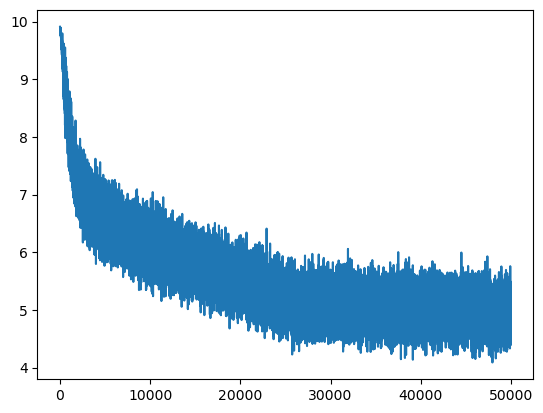

In [122]:
model2.plotloss()

In [124]:
x = model2.layers[-1].get_probs()
x = x[0]
print("stop token prob:", x[0])
print("max prob:", x.max())

stop token prob: 7.13573088139625e-06
max prob: 0.1376417131996628


In [125]:
for layer in model2.layers:
    if isinstance(layer, model2.BatchNorm):
        print("bngain range:", layer.bngain.min(), layer.bngain.max())
        print("bngain mean:", layer.bngain.mean())

bngain range: 0.9372987579428183 1.2501643065199464
bngain mean: 1.0590473365251922
bngain range: 1.1317805762957436 1.6691029440075444
bngain mean: 1.4406617125708052


my stop token probability is still extremely low, so i'm still getting the never ending sentences when i sample from the model. i thought this might be because of tanh saturation so i'm switching to ReLU with a lower learning rate.

In [19]:
dims = 64

model3 = MLP(Xtr, Ytr, batch_size=128, dims=dims, vocab_size=vocab_size)

model3.InputLayer(model3)
model3.LinearLayer(model3, context_size*dims, 512)
model3.BatchNorm(model3, 512)
model3.ReLU(model3)
model3.LinearLayer(model3, 512, 512)
model3.BatchNorm(model3, 512)
model3.ReLU(model3)
model3.LinearLayer(model3, 512, vocab_size)
model3.SoftMax(model3)

In [20]:
model3.train(50000,0.01,0.0001) # acidentally used 0.0001 instead of 0.001 for the second half lr, hence the high loss

0/50000: loss=9.8510
2500/50000: loss=6.9628
5000/50000: loss=6.9663
7500/50000: loss=6.6283
10000/50000: loss=5.7687
12500/50000: loss=6.1350
15000/50000: loss=6.4090
17500/50000: loss=6.3420
20000/50000: loss=6.2054
22500/50000: loss=6.4855
25000/50000: loss=5.6459
27500/50000: loss=6.0217
30000/50000: loss=6.6717
32500/50000: loss=6.0737
35000/50000: loss=6.5029
37500/50000: loss=6.0900
40000/50000: loss=6.3769
42500/50000: loss=6.5486
45000/50000: loss=6.3380
47500/50000: loss=5.9182
50000/50000: loss=6.0030


In [139]:
x = model3.layers[-1].get_probs()
x = x[0]
print("stop token prob:", x[0])
print("max prob:", x.max())

stop token prob: 2.1482527288703855e-05
max prob: 0.02801431193996605


My stop token is still at a probability around 0, so i'm starting to doubt it's an issue with my activation function. i thought it might be an issue with the data, that there aren't enough sentence ends or my data processing is not effectively capturing the sentence ends in my dataset, so i ran the following code.

In [135]:
stop_token_count = np.sum(Ytr == 0)
total_tokens = len(Ytr)
print("stop token frequency:", stop_token_count / total_tokens)
print("expected prob if perfectly calibrated:", stop_token_count / total_tokens)

stop token frequency: 0.0
expected prob if perfectly calibrated: 0.0


In [136]:
print("Ytr unique values sample:", np.unique(Ytr)[:20])
print("Xtr shape:", Xtr.shape)
print("Ytr shape:", Ytr.shape)
print("sample Xtr row:", Xtr[0])
print("sample Ytr value:", Ytr[0])

Ytr unique values sample: [ 1  2  3  4  5  8  9 10 11 12 13 14 15 16 17 19 20 21 22 23]
Xtr shape: (159558, 4)
Ytr shape: (159558,)
sample Xtr row: [0 0 0 0]
sample Ytr value: 11606


it's clear i've made the fatal flaw of literally not adding the ending token to the end of each sentence. so, i'm adding that in now and will train the model again.

In [15]:
dims = 64

# using sample layers/sizes as model2 since it got me a pretty low loss

model4 = MLP(Xtr, Ytr, batch_size=128, dims=dims, vocab_size=vocab_size)

model4.InputLayer(model4)
model4.LinearLayer(model4, context_size*dims, 512)
model4.BatchNorm(model4, 512)
model4.Tanh(model4)
model4.LinearLayer(model4, 512, 512)
model4.BatchNorm(model4, 512)
model4.Tanh(model4)
model4.LinearLayer(model4, 512, vocab_size)
model4.SoftMax(model4)

# on model 2, loss started bouncing around on the last ~20k iterations, so i've reduced it from 0.005 to 0.001
model4.train(50000, 0.05, 0.001)

0/50000: loss=9.8803
2500/50000: loss=6.9244
5000/50000: loss=6.3880
7500/50000: loss=6.0908
10000/50000: loss=5.7387
12500/50000: loss=6.0437
15000/50000: loss=5.5683
17500/50000: loss=5.3361
20000/50000: loss=5.5803
22500/50000: loss=5.2741
25000/50000: loss=5.4699
27500/50000: loss=5.6200
30000/50000: loss=4.6691
32500/50000: loss=5.3211
35000/50000: loss=4.8638
37500/50000: loss=4.7220
40000/50000: loss=4.7639
42500/50000: loss=5.0170
45000/50000: loss=5.3706
47500/50000: loss=5.2344
50000/50000: loss=5.0288


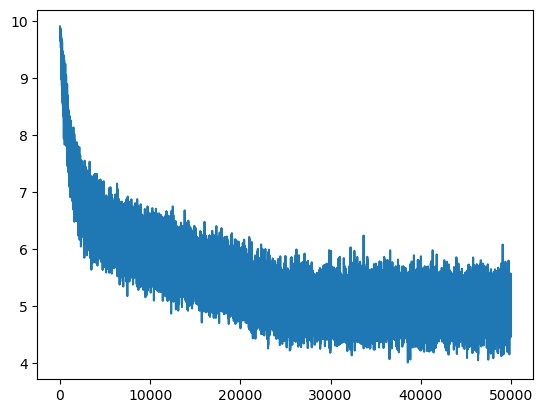

In [196]:
model4.plotloss()

In [173]:
x = model4.layers[-1].get_probs()
x = x[0]
print("stop token prob:", x[0])
print("max prob:", x.max())

stop token prob: 0.013342991292348196
max prob: 0.16883807597420228


In [174]:
model4.sample(10)

i have harden'd catesby, and sport: i cannot public; humour, i fourteen; broke take down the trow; of the thomas but no dukedom i'll not thy tongue still tear,.
for either prince; orphans,.
duke vincentio: i'll was no stain will not sleep.
see, dishonour not left it, fair as thou lascivious the world's darken'd the necessity and her conveyed lords enough with and tellus; instigation, out been now nobleman: i'll change a gentleman of a mighty royal crown in norfolk and what an requisite hath broke for i shall.
sicinius: have you not.
queen elizabeth: it after-love by hang'd.
duke vincentio: thine is clarence to so when care by any behalf that of depart, bepaint being regard an dress'd with the eye, of army; that is subjects by very housewife debating lustier with wink; allowed of split.
buckingham: they do withdraw: some to dew-dropping their by-words straying the villain: are music where more day, and corioli, then to the other, they live to cheerfully and pitchy.
now, in this name.
ka

yay! it seems to be working! the stop token probability is around 0.013. the sample sentences vary in length quite drastically but this may be expected considering the context size is only 4. that being said, i'm wondering if there are other causes of this due to the size/complexity of my model.

next, i'm going to use the dev set to evaluate the different models i've made and see which perform best/give the best results. first, i need to rerun the models with the added end token.

In [13]:
def evaluate_loss(m, X, Y):
        m.training = False
        total_loss = 0
        batch_count = 0
        for i in range(0, X.shape[0], m.batch_size):
            j = min(i + m.batch_size, X.shape[0])
            Xb, m.Yb = X[i:j], Y[i:j]

            x = m.layers[0].C[Xb].reshape(j - i, -1)
            for layer in m.layers[1:]:
                x = layer.forward(m, x)
            
            logprobs = np.log(x + 1e-8)
            loss = -np.mean(logprobs[range(j - i), m.Yb])
            total_loss += loss
            batch_count += 1
        
        return total_loss/batch_count 

In [28]:
print("MODEL 1:")
for layer in model.layers:
    print(layer)
print("dev loss:")
print(evaluate_loss(model, Xdev, Ydev))

print("\n\nMODEL 2:")
for layer in model2.layers:
    print(layer)
print("dev loss:")
print(evaluate_loss(model2, Xdev, Ydev))

print("\n\nMODEL 3:")
for layer in model3.layers:
    print(layer)
print("dev loss:")
print(evaluate_loss(model3, Xdev, Ydev))

print("\n\nMODEL 4:")
for layer in model4.layers:
    print(layer)
print("dev loss:")
print(evaluate_loss(model4, Xdev, Ydev))

MODEL 1:
dev loss:
6.280343235144769


MODEL 2:
dev loss:
6.35701566112504


MODEL 3:
dev loss:
6.40507088218899


MODEL 4:
dev loss:
6.311217610116242


i doubt this is the most standard/effective way to utilize the dev set, but for the sake of learning and time, i'm going to just calculate the loss on the dev set for each model and compare them.

it looks like model 2 is by far performing the best at around 6.2 while everything else is around 5.2 but this is before i've retrained all the models w/ the new model/stop token changes. this is interesting to me considering that it is the exact same as model 4, with the only difference being that model 4 has a 0.001 learning rate for the second half of training as opposed to model 2's 0.005. i'm wondering if this was a one-off case, so i'm going to rerun the model.

update: i've rerun the cell above this after rerunning the models. model 4 runs the best but is similar to model 2, which is expected. all models have dev losses around 6.2-6.4 now. this is a lot more aligned with what i'd expect considering the complexity of the different models.

to refresh, final iteration of training produced the following losses on the dev set: <br>
model: 5.8<br>
model 2: 4.4<br>
model 3: 6.0<br>
model 4: 5.0<br>

while models 2 and 4 have the lowest training loss, their dev losses are significantly higher than their training losses, which indicates that they are overfitting to the training data. this tracks for the following reasons:
- model 1 is a much simpler model than models 2 and 4, so it is less likely to overfit to the training data. this is reflected in the fact that its dev loss is much closer to its training loss compared to models 2 and 4.
- model 3 used an LR2 of 0.0001 (a typo since i meant to set it to 0.001) which would have caused it to not train much in the second half of training and therefore not overfit as much.

i'm also going to sample to see which come up with the best sentences and see if that is aligned with the dev losses. so when i sample from the first model, i'm getting the stop token issue again. this indicates that i likely forgot to rerun it since the other 3 models are sampling fine.

In [30]:
print("MODEL:")
model.sample(5)
print("MODEL2:")
model2.sample(5)
print("MODEL3:")
model3.sample(5)
print("MODEL4:")
model4.sample(5)

MODEL:
juliet: may she spake sleep, and honour thus do: and for me found from this in gadding midwife thy name is graced sir nor which which dog, out as thread kindle it; and these deputed losing.
capulet: i heard to that night us.
menenius: o, let me do i says an day to bettering and from definitive.
romeo: and relent up by any associated.
hermione: i have heard rages, their heartily were by me but is forth.
MODEL2:
pompey: if you be exhales of your brother range with your labour.
miranda: we chief the bloody create, i'll know, of thy love, let me well in froth, there's not this.
curtis: o, swear his potch he shall lay his highness' harm; hath power that sea-side out his.
romeo: on the est,' doctors angelo for ten.
tranio: that's shall to all her rather shall have amerce my therefore; of great birth; hollow; duke of red-look'd burgundy and i am too forward of thy prosperity by that prate banquet make good caution in this folly; should be the eager.
MODEL3:
first citizen: is't, against

honestly, all four models samples look quite similar at first glance, which tracks considering they all have similar training losses. while each varies, there doesn't seem to be a clear winner. since i'm not a linguist, i'm going to outsource to an LLM to evaluate the samples in a methodical, factual way and see what it thinks about the quality of the sentences from each model.


| Aspect | Model 1 | Model 2 | Model 3 | Model 4 |
|--------|---------|---------|---------|---------|
| Syntactic coherence | Frequent broken clauses, conjunctions dangling mid-phrase | Longest sentences with occasional working subordination | Short clauses that mostly hold together, breaks down in longer phrases | Coherent phrases but loses structure mid-sentence |
| Shakespearean register | Vocabulary fits but words strung together randomly | Strongest — "red-look'd burgundy", clause rhythm feels period-appropriate | Hits the register occasionally but inconsistent | Fragmented — reads more as noise than stylistic output |
| Character/context plausibility | Mixes plays entirely (Romeo, Menenius, Hermione) | Also mixes plays but transitions less jarring | Best — First Citizen, Brutus, Coriolanus all from Coriolanus | Volumnia appears with no prior context; mostly no named characters |
| Sentence length/variety | Short, simple | Longest and most varied | Mid-length, uniform | Mid-length but fragmented |

*Evaluated by Claude (Anthropic) — qualitative assessment across two generated samples per model.*

that being said, i don't trust this evaluation fully either because it's based on just 5 samples per model and different LLMs are giving different feedback. i'm going to with model 4 since it has a good training loss but is less overfit than model 2. but, there wasn't necessarily a clear winner in the samples so i'm not going to put too much weight on this decision.

In [31]:
evaluate_loss(model4, Xte, Yte)

np.float64(6.277156204204709)

YAY! this our final model test loss: 6.27. that's a considerable improvement from the initial 9.9.

this definitely isn't the best model that could be made (not even close) but the purpose of this notebook was to learn deeply about how MLPs work and how to implement them from scratch, so i'm happy with the results and the learnings along the way.